## 0. Введение

Этот ноутбук демонстрирует базовый запуск обучения детектора текста `EAST` в версии `0.1.11` и выше. В примере показано, как использовать встроенные средства библиотеки `manuscript-ocr` для обучения собственной модели детекции на размеченных данных в формате COCO.

Для быстрого теста в примере может использоваться сокращенный сценарий обучения с минимальным числом эпох и небольшим размером батча, поэтому ноутбук предназначен прежде всего для демонстрации процесса запуска обучения.

Таким образом, библиотека `manuscript-ocr` предоставляет возможность обучать детекторы текста на собственных данных. Более подробная информация о параметрах обучения и доступных настройках приведена в полной документации проекта: https://konstantinkozhin.github.io/manuscript-ocr/0.1.10/en/api/detectors.html

Минимальные технические требования для запуска примера:

- Python 3.8+
- не менее 12 ГБ оперативной памяти
- NVIDIA GPU с объемом видеопамяти не менее 8 ГБ

Следует учитывать, что данный пример относится к обучению модели детекции, поэтому запуск на GPU является рекомендуемым сценарием. Запуск на CPU возможен, но будет существенно медленнее и не рассматривается как базовый вариант для апробации.


## 1. Установка зависимостей

In [ ]:
#может потребовать перезапуска среды в Google Colab
!pip install "manuscript-ocr[dev]>=0.1.12"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.2/574.2 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.3/69.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.

In [ ]:
# Затем обновите PyTorch (если требуется) на GPU версию, совместимую с вашей версией CUDA (например, для CUDA 11.8):
!pip install --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu118

^C


## 2. Скачивание данных

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

from tqdm.auto import tqdm

base_url = "https://huggingface.co/datasets/anna4uonline/YeniseiGovReports-TD/resolve/main"
dataset_root = Path("datasets") / "YeniseiGovReports-TD"
dataset_root.mkdir(parents=True, exist_ok=True)

files = {
    "train_annotations": "train.json",
    "val_annotations": "test.json",
    "train_images_zip": "train_images.zip",
    "val_images_zip": "test_images.zip",
}

def download_with_progress(url: str, out_path: Path):
    if out_path.exists():
        print(f"Already exists: {out_path}")
        return

    last = [0]
    with tqdm(
        desc=f"Downloading {out_path.name}",
        unit="B",
        unit_scale=True,
        unit_divisor=1024,
    ) as pbar:
        def reporthook(block_num, block_size, total_size):
            if total_size > 0:
                pbar.total = total_size
            downloaded = block_num * block_size
            pbar.update(downloaded - last[0])
            last[0] = downloaded

        urlretrieve(url, out_path, reporthook=reporthook)

def extract_zip_once(zip_path: Path, extract_to: Path):
    marker = extract_to / f".{zip_path.stem}.done"
    if marker.exists():
        print(f"Already extracted: {zip_path.name}")
        return

    print(f"Extracting {zip_path.name} ...")
    with ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    marker.touch()

def resolve_images_dir(root: Path, split_name: str) -> Path:
    direct = root / f"{split_name}_images"
    nested = direct / f"{split_name}_images"
    if nested.exists():
        return nested
    if direct.exists():
        return direct
    raise FileNotFoundError(f"Could not find extracted folder for {split_name}_images")

# Скачивание файлов датасета
for _, filename in files.items():
    download_with_progress(
        f"{base_url}/{filename}",
        dataset_root / filename,
    )

# Распаковка архивов с изображениями
extract_zip_once(dataset_root / "train_images.zip", dataset_root)
extract_zip_once(dataset_root / "test_images.zip", dataset_root)

# Пути для EAST.train(...)
train_images = str(resolve_images_dir(dataset_root, "train"))
train_annotations = str(dataset_root / "train.json")

# В датасете нет отдельного val split, поэтому для валидации используем test split
val_images = str(resolve_images_dir(dataset_root, "test"))
val_annotations = str(dataset_root / "test.json")

print("train_images      =", train_images)
print("train_annotations =", train_annotations)
print("val_images        =", val_images)
print("val_annotations   =", val_annotations)


Extracting train_images.zip ...
Extracting test_images.zip ...
train_images      = datasets/YeniseiGovReports-TD/train_images
train_annotations = datasets/YeniseiGovReports-TD/train.json
val_images        = datasets/YeniseiGovReports-TD/test_images
val_annotations   = datasets/YeniseiGovReports-TD/test.json


## 3. Запуск обучения

In [2]:
from manuscript.detectors import EAST


# Для быстрого теста используем test split и как train, и как val
train_images = val_images
train_annotations = val_annotations

EAST.train(
    train_images=train_images,
    train_anns=train_annotations,
    val_images=val_images,
    val_anns=val_annotations,
    epochs=1,
    batch_size=1,
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s]


Training configuration saved to: /content/experiments/resnet_quad/training_config.json


/usr/local/lib/python3.12/dist-packages/manuscript/detectors/_east/train_utils.py:372: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Pre-training validation: Loss=66.2541, Dice=0.1850


...

/usr/local/lib/python3.12/dist-packages/manuscript/detectors/_east/train_utils.py:375: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast()


  [checkpoint] Saved best_loss.pth  (val_loss=60.7959)
  [checkpoint] Saved best_dice.pth  (val_dice=0.2545)
Attempting to export best model to ONNX...
Loading checkpoint from /content/experiments/resnet_quad/checkpoints/best_loss.pth...
Auto-detecting backbone architecture...
   Detected 114 layer3 parameters
   Auto-detected backbone: resnet50

Loading PyTorch model...
Loaded pretrained model from /content/experiments/resnet_quad/checkpoints/best_loss.pth
Model architecture: EASTWrapper
Input shape: torch.Size([1, 3, 1024, 1024])
Output shapes:
  - score_map: torch.Size([1, 1, 256, 256])
  - geo_map: torch.Size([1, 8, 256, 256])

Exporting to ONNX (opset 14)...


/usr/local/lib/python3.12/dist-packages/manuscript/detectors/_east/__init__.py:1282: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0410 11:16:53.903000 2671 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0410 11:16:55.211000 2671 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scal

Applied 114 of general pattern rewrite rules.
[OK] ONNX model saved to: /content/experiments/resnet_quad/checkpoints/best_model.onnx

Verifying ONNX model...
[OK] ONNX model is valid

Simplifying ONNX model...
[OK] ONNX model simplified

Testing ONNX inference...
[OK] ONNX inference works!
  ONNX score_map shape: (1, 1, 256, 256)
  ONNX geo_map shape: (1, 8, 256, 256)

Comparing ONNX vs PyTorch outputs...
  Max difference in score_map: 0.000001
  Max difference in geo_map: 0.000005
  [OK] Outputs match!

[OK] Export complete! Model size: 107.5 MB

=== Summary ===
Backbone: resnet50
Input shape: [batch_size, 3, 1024, 1024]
Output shapes:
  - score_map: [batch_size, 1, H, W]
  - geo_map: [batch_size, 8, H, W]
ONNX model exported successfully: /content/experiments/resnet_quad/checkpoints/best_model.onnx


EASTModel(
  (backbone): ResNetFeatureExtractor(
    (extractor): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Module(
        (0): Module(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

По окончании обучения лучшая по точности модель автоматически конвертируется в `ONNX` формат.

Сообщение `[OK] Export complete!` означает, что экспорт модели завершен успешно.

Строки

- `Comparing ONNX vs PyTorch outputs...`
- `Max difference in score_map: 0.000001`
- `Max difference in geo_map: 0.000005`
- `[OK] Outputs match!`

показывают, что после экспорта результаты ONNX-модели практически совпадают с результатами исходной PyTorch-модели. Это означает, что конвертация выполнена корректно и без существенных отклонений.

## 4. Инференс экспортированной модели

После обучения и экспорта детектор можно сразу использовать для инференса. В данном примере загружается тестовое изображение `img1.jpeg` из основного репозитория и выполняется детекция текста с помощью экспортированной модели `EAST`.

[EAST] Device configuration:
  Requested device: cpu
  Requested providers: ['CPUExecutionProvider']
  Active providers: ['CPUExecutionProvider']
  Running on: CPUExecutionProvider
Результат детекции:
blocks=[Block(lines=[Line(text_spans=[TextSpan(polygon=[(2698.813720703125, -33.50286865234375), (3097.20263671875, -33.50286865234375), (3097.20263671875, 181.91436767578125), (2698.813720703125, 181.91436767578125)], detection_confidence=0.9999979138374329, text=None, recognition_confidence=None, order=0), TextSpan(polygon=[(2773.52734375, -74.7732162475586), (3134.117919921875, -74.7732162475586), (3134.117919921875, 172.37628173828125), (2773.52734375, 172.37628173828125)], detection_confidence=0.9999922513961792, text=None, recognition_confidence=None, order=1), TextSpan(polygon=[(2535.368408203125, -49.96234130859375), (2899.06884765625, -49.96234130859375), (2899.06884765625, 160.8380126953125), (2535.368408203125, 160.8380126953125)], detection_confidence=0.999988317489624, text=N

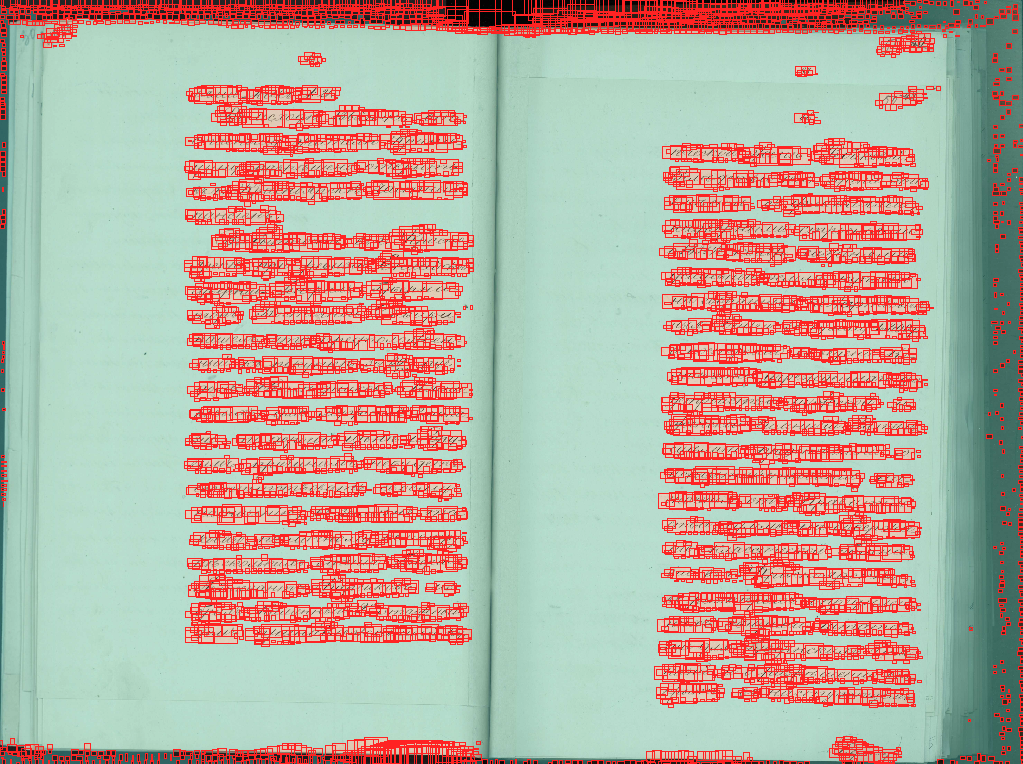

In [6]:
from pathlib import Path
from urllib.request import urlretrieve

from IPython.display import display

from manuscript.detectors import EAST
from manuscript.utils import visualize_page

exp_dir = Path("experiments") / "resnet_quad"

image_url = "https://raw.githubusercontent.com/konstantinkozhin/manuscript-ocr/main/example/images/img1.jpeg"
image_path = Path("img1.jpeg")

if not image_path.exists():
    urlretrieve(image_url, image_path)

detector = EAST(
    weights=str(exp_dir / "checkpoints/best_model.onnx"),
)

page = detector.predict(str(image_path))

print("Результат детекции:")
print(page)

vis_img = visualize_page(
    str(image_path),
    page,
    thickness=1,
    max_size=1024,
)

display(vis_img)

Следует учитывать, что приведенный выше результат носит демонстрационный характер, поскольку модель в данном примере обучалась только `1` эпоху.

Таким образом, `manuscript-ocr` предоставляет возможность обучать собственные модели детекции текста на пользовательских данных и экспортировать полученные веса для последующего использования.